In [1]:
!pip install -q pymupdf4llm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.3/77.3 kB 1.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 46.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 49.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 46.9 MB/s eta 0:00:0000:0100:01


In [2]:
import pymupdf4llm

# Extracts text and saves extracted images to disk
pdf_path = "../input/datasets/khoayang/attention/1706.03762v7.pdf"
md = pymupdf4llm.to_markdown(
    pdf_path, 
    write_images=True,           # Enables image extraction
    image_path="./images",       # Directory to save the images
    image_format="png",          # Format of the saved images
    dpi=150                      # Resolution for rendered elements
)


=== Document parser messages ===
Using Tesseract for OCR processing.
OCR on page.number=2/3.
OCR on page.number=3/4.



In [ ]:
print(md)

In [ ]:
from IPython.display import Markdown, display, Image
import os
for f in sorted(sorted(os.listdir("./images"))):
    display(Image(filename=os.path.join("./images", f)))

In [ ]:
import fitz
import io
from PIL import Image
doc = fitz.open(pdf_path)

for page_num, page in enumerate(doc):
    imgs = page.get_images(full=True)
    if imgs:
        print(f"Page {page_num}: {len(imgs)} images")
        for img in imgs:
            xref = img[0]
    
            rects = page.get_image_rects(xref)
            base = doc.extract_image(xref)
            print(
                "xref=", xref,
                "rects=", rects
            )

            display(Image.open(io.BytesIO(base["image"])))

In [ ]:
import fitz
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

doc = fitz.open(pdf_path)

dpi = 300
zoom = dpi / 72

for page_num, page in enumerate(doc):

    pix = page.get_pixmap(matrix=fitz.Matrix(zoom, zoom), alpha=False)

    img = np.frombuffer(pix.samples, dtype=np.uint8)
    img = img.reshape(pix.height, pix.width, pix.n)

    fig, ax = plt.subplots(figsize=(12, 16))

    ax.imshow(img)

    for img_info in page.get_images(full=True):
        xref = img_info[0]

        for rect in page.get_image_rects(xref):

            ax.add_patch(
                patches.Rectangle(
                    (rect.x0 * zoom, rect.y0 * zoom),
                    rect.width * zoom,
                    rect.height * zoom,
                    fill=False,
                    linewidth=3
                )
            )

            ax.text(
                rect.x0 * zoom,
                rect.y0 * zoom - 10,
                f"xref={xref}",
                fontsize=12
            )

    ax.set_title(f"Page {page_num}")
    ax.axis("off")

    plt.show()

In [1]:
!pip install -U -q docling

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.5 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 525.7/525.7 kB 5.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 286.7/286.7 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.0/94.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 33.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.0/43.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 90.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8

In [2]:
from huggingface_hub import login

login("hf_YOUR_TOKEN_HERE")

In [19]:
import pkgutil
import importlib
import inspect
import docling.datamodel

# for m in pkgutil.iter_modules(docling.datamodel.__path__):
#     mod = importlib.import_module(
#         f"docling.datamodel.{m.name}"
#     )

#     print(f"\n=== {m.name} ===")

#     for name, obj in inspect.getmembers(mod):
#         if inspect.isclass(obj):
#             print(name)

In [21]:
from docling.datamodel import vlm_model_specs

print(
    vlm_model_specs.GRANITEDOCLING_TRANSFORMERS.model_dump()
)

{'kind': 'inline_model_options', 'prompt': 'Convert this page to docling.', 'scale': 2.0, 'max_size': None, 'temperature': 0.0, 'repo_id': 'ibm-granite/granite-docling-258M', 'revision': 'main', 'trust_remote_code': False, 'load_in_8bit': True, 'llm_int8_threshold': 6.0, 'quantized': False, 'inference_framework': <InferenceFramework.TRANSFORMERS: 'transformers'>, 'transformers_model_type': <TransformersModelType.AUTOMODEL_IMAGETEXTTOTEXT: 'automodel-imagetexttotext'>, 'transformers_prompt_style': <TransformersPromptStyle.CHAT: 'chat'>, 'response_format': <ResponseFormat.DOCTAGS: 'doctags'>, 'torch_dtype': None, 'supported_devices': [<AcceleratorDevice.CPU: 'cpu'>, <AcceleratorDevice.CUDA: 'cuda'>, <AcceleratorDevice.XPU: 'xpu'>], 'stop_strings': ['</doctag>', '<|end_of_text|>'], 'custom_stopping_criteria': [], 'extra_generation_config': {'skip_special_tokens': False}, 'extra_processor_kwargs': {}, 'use_kv_cache': True, 'max_new_tokens': 8192, 'track_generated_tokens': False, 'track_inp

In [10]:
print(vlm_model_specs.GRANITEDOCLING_TRANSFORMERS)
print()
print(vlm_model_specs.GRANITE_VISION_TRANSFORMERS)

kind='inline_model_options' prompt='Convert this page to docling.' scale=2.0 max_size=None temperature=0.0 repo_id='ibm-granite/granite-docling-258M' revision='main' trust_remote_code=False load_in_8bit=True llm_int8_threshold=6.0 quantized=False inference_framework=<InferenceFramework.TRANSFORMERS: 'transformers'> transformers_model_type=<TransformersModelType.AUTOMODEL_IMAGETEXTTOTEXT: 'automodel-imagetexttotext'> transformers_prompt_style=<TransformersPromptStyle.CHAT: 'chat'> response_format=<ResponseFormat.DOCTAGS: 'doctags'> torch_dtype=None supported_devices=[<AcceleratorDevice.CPU: 'cpu'>, <AcceleratorDevice.CUDA: 'cuda'>, <AcceleratorDevice.XPU: 'xpu'>] stop_strings=['</doctag>', '<|end_of_text|>'] custom_stopping_criteria=[] extra_generation_config={'skip_special_tokens': False} extra_processor_kwargs={} use_kv_cache=True max_new_tokens=8192 track_generated_tokens=False track_input_prompt=False

kind='inline_model_options' prompt='Convert this page to markdown. Do not miss an

In [3]:
from docling.datamodel.pipeline_options import VlmConvertOptions, PdfPipelineOptions
import json
p = PdfPipelineOptions()
print(
    json.dumps(
        p.model_dump(mode="json"),
        indent=2,
        ensure_ascii=False
    )
)

{
  "document_timeout": null,
  "accelerator_options": {
    "num_threads": 4,
    "device": "auto",
    "cuda_use_flash_attention2": false
  },
  "enable_remote_services": false,
  "allow_external_plugins": false,
  "artifacts_path": null,
  "do_picture_classification": false,
  "picture_classification_options": {
    "engine_options": {
      "engine_type": "transformers",
      "top_k": null
    },
    "model_spec": {
      "name": "document_figure_classifier_v2",
      "repo_id": "docling-project/DocumentFigureClassifier-v2.5",
      "revision": "main",
      "engine_overrides": {}
    }
  },
  "do_picture_description": false,
  "picture_description_options": {
    "batch_size": 8,
    "scale": 2.0,
    "picture_area_threshold": 0.05,
    "classification_allow": null,
    "classification_deny": null,
    "classification_min_confidence": 0.0
  },
  "do_chart_extraction": false,
  "chart_extraction_options": {
    "kind": "chart_extraction",
    "model": "granite-vision-v4",
    "cha

In [34]:
from docling.document_converter import (
    DocumentConverter,
    PdfFormatOption,
)
from docling.pipeline.standard_pdf_pipeline import StandardPdfPipeline
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions

pipeline_options = PdfPipelineOptions()

pipeline_options.do_ocr = True
pipeline_options.do_table_structure = True
pipeline_options.do_picture_description = False
pipeline_options.generate_page_images = True
pipeline_options.generate_picture_images = True
pipeline_options.do_formula_enrichment = True
pipeline_options.do_code_enrichment = True

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(
            pipeline_cls=StandardPdfPipeline,
            pipeline_options=pipeline_options,
        )
    }
)

In [35]:
# print(pipeline_options)
print("OCR:", pipeline_options.do_ocr)
print("Table:", pipeline_options.do_table_structure)
print("Picture Description:", pipeline_options.do_picture_description)

print("Generate Page Images:", pipeline_options.generate_page_images)
print("Generate Picture Images:", pipeline_options.generate_picture_images)

print("Formula Enrichment:", pipeline_options.do_formula_enrichment)
print("Code Enrichment:", pipeline_options.do_code_enrichment)

OCR: True
Table: True
Picture Description: False
Generate Page Images: True
Generate Picture Images: True
Formula Enrichment: True
Code Enrichment: True


In [112]:
import gc
import torch
from docling_core.types.doc import ImageRefMode
pdf_path = "../input/datasets/khoayang/attention/1706.03762v7.pdf"
gc.collect()
torch.cuda.empty_cache()
result = converter.convert(pdf_path)

md = result.document.export_to_markdown()

In [108]:
# pdf_opt = converter.format_to_options[InputFormat.PDF]

# pic_opt = pdf_opt.pipeline_options.picture_description_options

# print(pic_opt.model_spec)

In [113]:
print(md)

Provided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works.

## Attention Is All You Need

Ashish Vaswani ∗ Google Brain avaswani@google.com Noam Shazeer ∗ Google Brain noam@google.com

Llion Jones ∗ Google Research llion@google.com Niki Parmar ∗ Google Research nikip@google.com Aidan N. Gomez ∗ † University of Toronto aidan@cs.toronto.edu Jakob Uszkoreit ∗ Google Research usz@google.com Łukasz Kaiser ∗ Google Brain lukaszkaiser@google.com Illia Polosukhin ∗ ‡

illia.polosukhin@gmail.com

## Abstract

The dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convol

In [30]:
from docling_core.types.doc import PictureItem

doc = result.document
for item, level in doc.iterate_items():
    if isinstance(item, PictureItem):
        # print(item)
        pass
pic = doc.pictures[0]
# ok
# print(pic.prov)
# print(pic.image)

In [29]:
for i, pic in enumerate(doc.pictures):
    image = pic.get_image(doc)
    
    print(image)
    image.save(f"figure_{i}.png")

<PIL.PngImagePlugin.PngImageFile image mode=RGB size=222x321 at 0x7DCE92C473E0>
<PIL.PngImagePlugin.PngImageFile image mode=RGB size=66x125 at 0x7DCE92C46CC0>
<PIL.PngImagePlugin.PngImageFile image mode=RGB size=120x167 at 0x7DCE92C46A80>
<PIL.PngImagePlugin.PngImageFile image mode=RGB size=384x203 at 0x7DCE92C452B0>
<PIL.PngImagePlugin.PngImageFile image mode=RGB size=381x434 at 0x7DCE92C474A0>
<PIL.PngImagePlugin.PngImageFile image mode=RGB size=378x404 at 0x7DCE92C46F60>


In [42]:
for i, pic in enumerate(doc.pictures):
    print(pic.self_ref)
    print(pic.captions)

#/pictures/0
[RefItem(cref='#/texts/25')]
#/pictures/1
[]
#/pictures/2
[RefItem(cref='#/texts/73')]
#/pictures/3
[RefItem(cref='#/texts/212')]
#/pictures/4
[RefItem(cref='#/texts/281')]
#/pictures/5
[RefItem(cref='#/texts/393')]


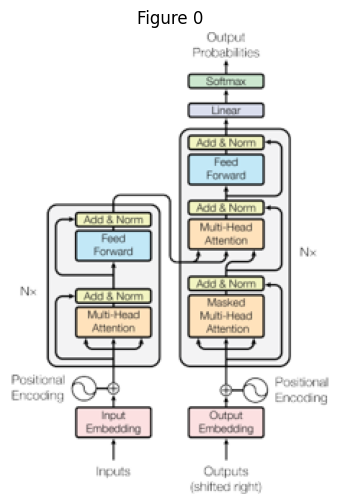

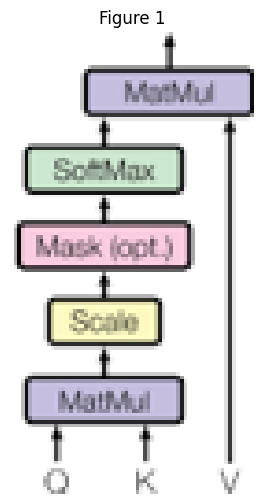

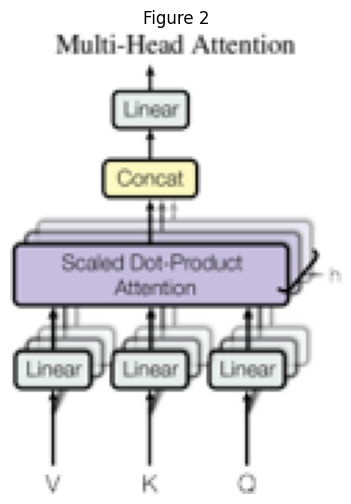

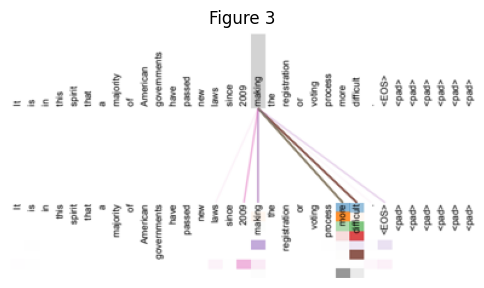

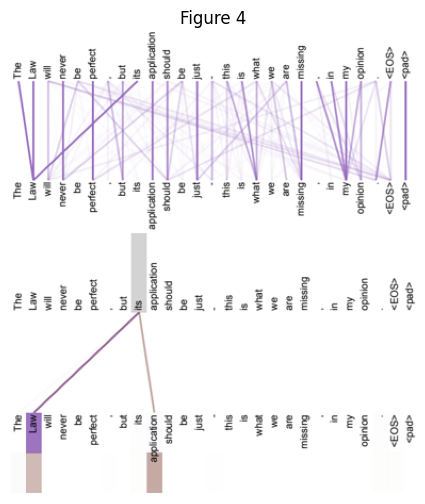

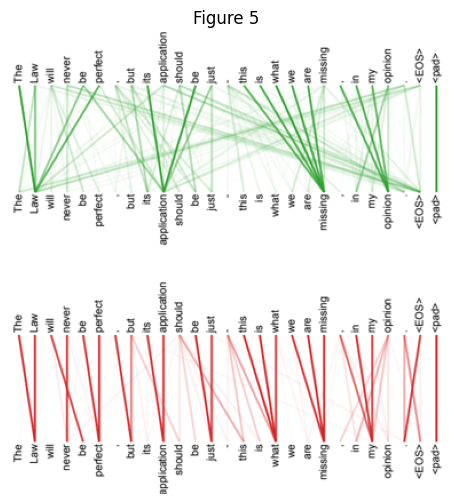

In [43]:
from PIL import Image
import matplotlib.pyplot as plt

for i in range(len(doc.pictures)):
    img = Image.open(f"figure_{i}.png")

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Figure {i}")
    plt.axis("off")
    plt.show()

In [58]:
doc.texts[2]

SectionHeaderItem(self_ref='#/texts/2', parent=RefItem(cref='#/body'), children=[], content_layer=<ContentLayer.BODY: 'body'>, meta=None, label=<DocItemLabel.SECTION_HEADER: 'section_header'>, prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=211.488, t=641.835626, r=399.89333760000005, b=626.3589814, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 25))], source=[], comments=[], orig='Attention Is All You Need', text='Attention Is All You Need', formatting=None, hyperlink=None, level=1)

In [57]:
for t in doc.texts:
    if getattr(t.label, "value", "") == "caption":

        print("Caption:")
        print(t.text)

        print("Belongs to:")
        print(t.parent.cref)

        print()

Caption:
Figure 1: The Transformer - model architecture.
Belongs to:
#/pictures/0

Caption:
Figure 2: (left) Scaled Dot-Product Attention. (right) Multi-Head Attention consists of several attention layers running in parallel.
Belongs to:
#/pictures/2

Caption:
Table 1: Maximum path lengths, per-layer complexity and minimum number of sequential operations for different layer types. n is the sequence length, d is the representation dimension, k is the kernel size of convolutions and r the size of the neighborhood in restricted self-attention.
Belongs to:
#/tables/0

Caption:
Table 2: The Transformer achieves better BLEU scores than previous state-of-the-art models on the English-to-German and English-to-French newstest2014 tests at a fraction of the training cost.
Belongs to:
#/tables/1

Caption:
Table 3: Variations on the Transformer architecture. Unlisted values are identical to those of the base model. All metrics are on the English-to-German translation development set, newstest2013.

In [60]:
text_map = {
    t.self_ref: t
    for t in doc.texts
}

for i, pic in enumerate(doc.pictures):

    p = pic.prov[0]

    print(
        i,
        p.page_no,
        p.bbox,
        bool(pic.captions)
    )

0 3 l=195.398681640625 t=719.1835632324219 r=416.5757751464844 b=398.17242431640625 coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'> True
1 4 l=173.01475524902344 t=697.9974975585938 r=239.46847534179688 b=572.7838592529297 coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'> False
2 4 l=346.6820373535156 t=721.2792892456055 r=467.1015930175781 b=553.9322662353516 coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'> True
3 13 l=118.71479797363281 t=693.2095718383789 r=503.24554443359375 b=490.0801696777344 coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'> True
4 14 l=121.0322494506836 t=621.1409301757812 r=501.9855651855469 b=186.8482666015625 coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'> True
5 15 l=120.37049865722656 t=607.4371490478516 r=498.2450256347656 b=202.76763916015625 coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'> True


In [66]:
text_map = {
    t.self_ref: t
    for t in doc.texts
}

dataset = []

for pic in doc.pictures:

    img = pic.get_image(doc)

    caption = None

    if pic.captions:
        caption = text_map[pic.captions[0].cref].text

    dataset.append({
        "image": img,
        "caption": caption,
        "picture_ref": pic.self_ref,
        "page": pic.prov[0].page_no,
        "bbox": pic.prov[0].bbox
    })

dataset[0]

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=222x321>,
 'caption': 'Figure 1: The Transformer - model architecture.',
 'picture_ref': '#/pictures/0',
 'page': 3,
 'bbox': BoundingBox(l=195.398681640625, t=719.1835632324219, r=416.5757751464844, b=398.17242431640625, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>)}

In [72]:
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration

In [114]:
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2.5-VL-3B-Instruct",
    torch_dtype="auto",
    device_map="auto"
)

processor = AutoProcessor.from_pretrained(
    "Qwen/Qwen2.5-VL-3B-Instruct"
)


Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

In [128]:
batch_messages = []
batch_images = [d["image"] for d in dataset]

SYSTEM_PROMPT = """
You are a helpful assistant.
"""

for image in batch_images:
    batch_messages.append([
        {
            "role": "system",
            "content": SYSTEM_PROMPT
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": "Describe this figure."}
            ]
        }
    ])

texts = [
    processor.apply_chat_template(
        msg,
        tokenize=False,
        add_generation_prompt=True
    )
    for msg in batch_messages
]
processor.tokenizer.padding_side = "left"
inputs = processor(
    text=texts,
    images=batch_images,
    return_tensors="pt",
    padding=True
).to(model.device)

len(inputs)

5

In [129]:
generated_ids = model.generate(
    **inputs,
    max_new_tokens=512
)
generated_ids_trimmed = [
    out_ids[len(in_ids):]
    for in_ids, out_ids in zip(
        inputs.input_ids,
        generated_ids
    )
]
output_text = processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False
)


In [130]:
print(output_text[0])

This figure depicts the architecture of a transformer-based model, specifically focusing on the encoder-decoder framework used for sequence-to-sequence tasks. Here's a detailed description of each component:

1. **Input Embedding**: The input data is first embedded into a higher-dimensional space using an embedding layer. This layer maps each input token to a vector representation.

2. **Positional Encoding**: Positional encoding is added to the input embeddings to capture the relative positions of tokens in the sequence. This helps the model understand the order and context of the tokens.

3. **Encoder**: The encoder consists of multiple layers, each containing:
   - **Multi-Head Attention**: This mechanism allows the model to attend to different parts of the input sequence simultaneously. It uses multiple attention heads to capture different aspects of the input.
   - **Add & Norm**: This step adds the output of the multi-head attention to the input embeddings and normalizes it to pr

In [131]:
for i, desc in enumerate(output_text):
    replacement = f"""
![Figure {i}](images/figure_{i}.png)

**Visual Description**

{desc}
"""

    md = md.replace(
        "<!-- image -->",
        replacement,
        1
    )

In [132]:
print(md)

Provided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works.

## Attention Is All You Need

Ashish Vaswani ∗ Google Brain avaswani@google.com Noam Shazeer ∗ Google Brain noam@google.com

Llion Jones ∗ Google Research llion@google.com Niki Parmar ∗ Google Research nikip@google.com Aidan N. Gomez ∗ † University of Toronto aidan@cs.toronto.edu Jakob Uszkoreit ∗ Google Research usz@google.com Łukasz Kaiser ∗ Google Brain lukaszkaiser@google.com Illia Polosukhin ∗ ‡

illia.polosukhin@gmail.com

## Abstract

The dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convol

In [5]:
from docling.datamodel.pipeline_options import VlmPipelineOptions
from docling.datamodel import vlm_model_specs
from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.pipeline.vlm_pipeline import VlmPipeline
from docling.datamodel.base_models import InputFormat

from copy import deepcopy

opt = deepcopy(
    vlm_model_specs.GRANITE_VISION_TRANSFORMERS
)

opt.scale = 1.0
opt.max_size = 1024
opt.max_new_tokens = 512

pipeline_options = VlmPipelineOptions(
    vlm_options=opt
)

pipeline_options.images_scale = 1.0

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(
            pipeline_cls=VlmPipeline,
            pipeline_options=pipeline_options,
        )
    }
)

In [6]:
print(pipeline_options)

document_timeout=None accelerator_options=AcceleratorOptions(num_threads=4, device='auto', cuda_use_flash_attention2=False) enable_remote_services=False allow_external_plugins=False artifacts_path=None do_picture_classification=False picture_classification_options=DocumentPictureClassifierOptions(engine_options=TransformersImageClassificationEngineOptions(engine_type=<ImageClassificationEngineType.TRANSFORMERS: 'transformers'>, top_k=None, torch_dtype=None, compile_model=True), model_spec=ImageClassificationModelSpec(name='document_figure_classifier_v2', repo_id='docling-project/DocumentFigureClassifier-v2.5', revision='main', engine_overrides={})) do_picture_description=False picture_description_options=PictureDescriptionVlmEngineOptions(batch_size=8, scale=2.0, picture_area_threshold=0.05, classification_allow=None, classification_deny=None, classification_min_confidence=0.0, engine_options=AutoInlineVlmEngineOptions(engine_type=<VlmEngineType.AUTO_INLINE: 'auto_inline'>, prefer_vllm

In [7]:
from docling.datamodel.pipeline_options import VlmPipelineOptions

print(VlmPipelineOptions.model_fields.keys())

NameError: name 'pipe' is not defined

In [ ]:
from docling.datamodel import vlm_model_specs

print(type(vlm_model_specs.GRANITE_VISION_TRANSFORMERS))

In [9]:
import gc
import torch
pdf_path = "../input/datasets/khoayang/attention/1706.03762v7.pdf"
gc.collect()
torch.cuda.empty_cache()
result = converter.convert(pdf_path)

md = result.document.export_to_markdown()

Loading weights:   0%|          | 0/815 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens', 'use_cache'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Encountered an error during conversion of document bdfaa68d8984f0dc02beaca527b76f207d99b666d31d1da728ee0728182df697:
Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/docling/pipeline/base_pipeline.py", line 272, in _build_document
    for p in pipeline_pages:  # Must exhaust!
             ^^^^^^^^^^^^^^

  File "/usr/local/lib/python3.12/dist-packages/docling/pipeline/base_pipeline.py", line 237, in _apply_on_pages
    yield from page_batch

  File "/usr/local/lib/python3.12/dist-packages/docling/models/vlm_pipeline_models/hf_transformers_model.py", line 197, in __call__
    predictions = list(self.process_images(images, user_prompts))
                  ^^^^^^^^^^^^^

RuntimeError: Pipeline VlmPipeline failed